# Dự đoán Mưa Ngày Mai — HMM & HMM + Fuzzy + ANFIS

**Dataset:** weatherAUS.csv (142K ngày, 49 địa điểm Úc)  
**So sánh với:** `Rain_Prediction_ANN.ipynb`  
**Pipeline:**
1. Tiền xử lý giống ANN (label encode, fill NaN, outlier removal, StandardScaler)
2. Rời rạc hóa features bằng KMeans → observation symbols
3. **HMM**: huấn luyện 2 HMM class-conditional (Rain / No Rain), dự đoán bằng log-likelihood ratio
4. **HMM + Fuzzy + ANFIS**: dùng LL-ratio làm membership input, tối ưu bằng Weighted LSE + GD

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Ready.')


Ready.


## 1. Load & Tiền xử lý

In [3]:
data = pd.read_csv('weatherAUS.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)

data['month'] = data.Date.dt.month
data['day']   = data.Date.dt.day
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
data['day_sin']   = np.sin(2 * np.pi * data['day'] / 31)
data['day_cos']   = np.cos(2 * np.pi * data['day'] / 31)

cat_cols = ['Location','WindGustDir','WindDir9am','WindDir3pm','RainToday','RainTomorrow']
le = LabelEncoder()
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])
    data[col] = le.fit_transform(data[col].astype(str))

num_cols = data.select_dtypes('float64').columns.tolist()
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

data = data.drop(columns=['Date','month','day'])
print(f'Shape: {data.shape}')
data.head(3)


Shape: (142193, 27)


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,month_sin,month_cos,day_sin,day_cos
0,9,8.0,24.3,0.0,3.4,6.3,7,30.0,12,7,...,7.0,14.4,23.6,0,3.6,1,-0.5,0.866025,0.201299,0.979530
1,9,14.0,26.9,3.6,4.4,9.7,1,39.0,0,13,...,3.0,17.5,25.7,1,3.6,1,-0.5,0.866025,0.394356,0.918958
2,9,13.7,23.4,3.6,5.8,3.3,7,85.0,3,5,...,7.0,15.4,20.2,1,39.8,1,-0.5,0.866025,0.571268,0.820763


In [4]:
target = data['RainTomorrow'].copy()
feat_cols = [c for c in data.columns if c != 'RainTomorrow']

scaler = StandardScaler()
data[feat_cols] = scaler.fit_transform(data[feat_cols])
data['RainTomorrow'] = target

# Same outlier bounds as Rain_Prediction_ANN.ipynb
data = data[(data['MinTemp'] < 2.3)  & (data['MinTemp'] > -2.3)]
data = data[(data['MaxTemp'] < 2.3)  & (data['MaxTemp'] > -2)]
data = data[(data['Rainfall'] < 4.5)]
data = data[(data['Evaporation'] < 2.8)]
data = data[(data['Sunshine'] < 2.1)]
data = data[(data['WindGustSpeed'] < 4) & (data['WindGustSpeed'] > -4)]
data = data[(data['WindSpeed9am'] < 4)]
data = data[(data['WindSpeed3pm'] < 2.5)]
data = data[(data['Humidity9am'] > -3)]
data = data.reset_index(drop=True)

X = data.drop(columns=['RainTomorrow']).values
y = data['RainTomorrow'].values
feat_names = data.drop(columns=['RainTomorrow']).columns.tolist()
print(f'After cleaning: X={X.shape}, Rain ratio={y.mean():.3f}')


After cleaning: X=(131991, 26), Rain ratio=0.218


In [5]:
N_OBS     = 8   # so ky hieu quan sat (KMeans clusters)
N_STATES  = 2   # so trang thai HMM moi class
WINDOW    = 5   # cua so truot (ngay)
THETA     = 1.5 # do rong bucket ANFIS

# KMeans discretize
print('KMeans discretizing...')
km = KMeans(n_clusters=N_OBS, random_state=42, n_init=10)
obs_all = km.fit_predict(X).astype(int)

# ANFIS features: 8 features du bao tot nhat cho mua
anfis_names = ['Humidity3pm','Humidity9am','Pressure3pm','Pressure9am',
               'Cloud3pm','Cloud9am','Sunshine','Rainfall']
anfis_idx = [feat_names.index(f) for f in anfis_names if f in feat_names]
X_anf = X[:, anfis_idx]
print(f'ANFIS features ({len(anfis_idx)}): {[feat_names[i] for i in anfis_idx]}')

# Temporal split 80/20 (data da sort by Date)
cut = int(len(y) * 0.8)
obs_tr, obs_te = obs_all[:cut], obs_all[cut:]
y_tr,   y_te   = y[:cut],       y[cut:]
Xa_tr,  Xa_te  = X_anf[:cut],   X_anf[cut:]
print(f'Train: {len(y_tr)} | Test: {len(y_te)}')
print(f'Train rain: {y_tr.mean():.3f} | Test rain: {y_te.mean():.3f}')


KMeans discretizing...
ANFIS features (8): ['Humidity3pm', 'Humidity9am', 'Pressure3pm', 'Pressure9am', 'Cloud3pm', 'Cloud9am', 'Sunshine', 'Rainfall']
Train: 105592 | Test: 26399
Train rain: 0.219 | Test rain: 0.217


## 2. HMM — Scaled Forward-Backward (Baum-Welch)

In [6]:
class HMM:
    def __init__(self, n_states, n_obs):
        self.N, self.M = n_states, n_obs
        self._init()

    def _init(self):
        self.pi = np.random.dirichlet(np.ones(self.N))
        self.A  = np.random.dirichlet(np.ones(self.N), size=self.N)
        B = np.ones((self.N, self.M)) * 0.1
        for i in range(self.N):
            B[i, i % self.M] += 2.0
        self.B = B / B.sum(axis=1, keepdims=True)

    def forward_scaled(self, obs):
        T = len(obs)
        alpha = np.zeros((T, self.N)); scales = np.zeros(T)
        alpha[0] = self.pi * self.B[:, obs[0]]
        scales[0] = alpha[0].sum() + 1e-300; alpha[0] /= scales[0]
        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ self.A) * self.B[:, obs[t]]
            scales[t] = alpha[t].sum() + 1e-300; alpha[t] /= scales[t]
        return alpha, scales

    def backward_scaled(self, obs, scales):
        T = len(obs); beta = np.zeros((T, self.N)); beta[-1] = 1.0
        for t in range(T-2, -1, -1):
            beta[t] = self.A @ (self.B[:, obs[t+1]] * beta[t+1])
            beta[t] /= scales[t+1]
        return beta

    def log_likelihood(self, obs):
        _, scales = self.forward_scaled(obs)
        return np.sum(np.log(scales + 1e-300))

    def log_likelihood_batch(self, windows):
        """Vectorized LL for (N_windows, T) array."""
        N_win, T = windows.shape
        alpha = self.pi[None,:] * self.B[:, windows[:,0]].T  # (N_win, N)
        scales = alpha.sum(axis=1) + 1e-300
        alpha /= scales[:, None]
        total_log = np.log(scales)
        for t in range(1, T):
            alpha = (alpha @ self.A) * self.B[:, windows[:,t]].T
            scales = alpha.sum(axis=1) + 1e-300
            alpha /= scales[:, None]
            total_log += np.log(scales)
        return total_log

    def fit(self, seqs, n_iter=100, tol=1e-3, verbose=True):
        prev_ll = -np.inf
        for it in range(n_iter):
            pi_n = np.zeros(self.N); A_n = np.zeros((self.N,self.N))
            B_n = np.zeros((self.N,self.M)); total_ll = 0.0
            for obs in seqs:
                T = len(obs)
                if T < 2: continue
                alpha, scales = self.forward_scaled(obs)
                beta = self.backward_scaled(obs, scales)
                total_ll += np.sum(np.log(scales + 1e-300))
                gamma = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True) + 1e-300
                xi = np.zeros((T-1, self.N, self.N))
                for t in range(T-1):
                    xi[t] = (alpha[t,:,None] * self.A
                             * self.B[:,obs[t+1]][None,:] * beta[t+1][None,:])
                    xi[t] /= xi[t].sum() + 1e-300
                pi_n += gamma[0]; A_n += xi.sum(axis=0)
                for k in range(self.M):
                    B_n[:,k] += gamma[obs==k].sum(axis=0)
            self.pi = pi_n / (pi_n.sum() + 1e-300)
            self.A  = A_n  / (A_n.sum(axis=1, keepdims=True) + 1e-300)
            self.B  = B_n  / (B_n.sum(axis=1, keepdims=True) + 1e-300)
            if verbose and (it % 20 == 0 or it == n_iter-1):
                print(f'  Iter {it+1:3d} | LL = {total_ll:.2f}')
            if abs(total_ll - prev_ll) < tol:
                print(f'  Hoi tu tai iter {it+1}'); break
            prev_ll = total_ll

print('HMM class OK.')


HMM class OK.


## 3. Huấn luyện HMM class-conditional

In [7]:
obs0 = obs_tr[y_tr == 0]
obs1 = obs_tr[y_tr == 1]
print(f'Class 0 (No Rain): {len(obs0)} ngay | Class 1 (Rain): {len(obs1)} ngay')

hmm0 = HMM(N_STATES, N_OBS)
hmm1 = HMM(N_STATES, N_OBS)

print('\nTraining HMM_0 (No Rain)...')
hmm0.fit([obs0], n_iter=100, tol=1e-3, verbose=True)

print('\nTraining HMM_1 (Rain)...')
hmm1.fit([obs1], n_iter=100, tol=1e-3, verbose=True)


Class 0 (No Rain): 82504 ngay | Class 1 (Rain): 23088 ngay

Training HMM_0 (No Rain)...
  Iter   1 | LL = -208911.93
  Iter  21 | LL = -140877.81
  Hoi tu tai iter 36

Training HMM_1 (Rain)...
  Iter   1 | LL = -67899.71
  Hoi tu tai iter 17


## 4. Dự đoán (HMM)

In [8]:
# Build test windows
test_wins = np.array([obs_te[i-WINDOW+1:i+1] for i in range(WINDOW-1, len(obs_te))])
y_te_w    = y_te[WINDOW-1:]

print(f'Computing batch log-likelihoods on {len(test_wins)} test windows...')
ll0_te = hmm0.log_likelihood_batch(test_wins)
ll1_te = hmm1.log_likelihood_batch(test_wins)

y_pred_hmm = (ll1_te > ll0_te).astype(int)
print(f'Done. Predicted rain ratio: {y_pred_hmm.mean():.3f} | Actual: {y_te_w.mean():.3f}')


Computing batch log-likelihoods on 26395 test windows...
Done. Predicted rain ratio: 0.522 | Actual: 0.217


## 5. Đánh giá — HMM

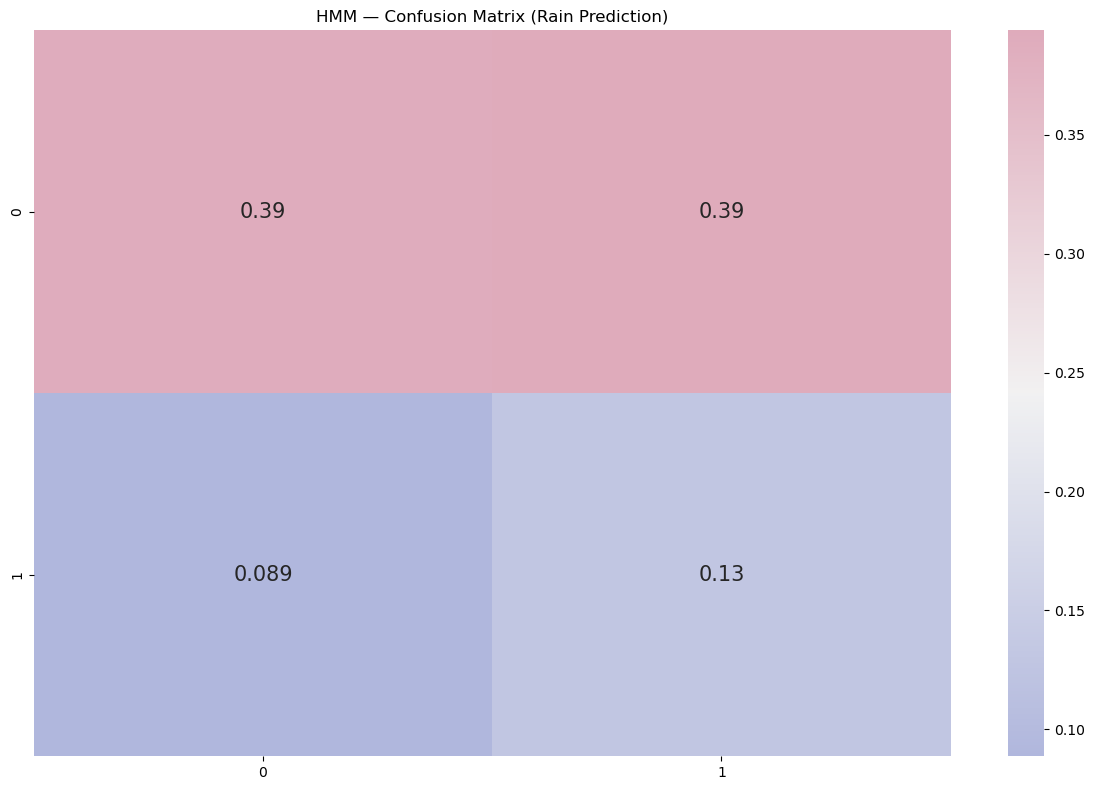

In [9]:
cmap1 = sns.diverging_palette(260, -10, s=50, l=75, n=5, as_cmap=True)
plt.subplots(figsize=(12, 8))
cf = confusion_matrix(y_te_w, y_pred_hmm)
sns.heatmap(cf / cf.sum(), cmap=cmap1, annot=True, annot_kws={'size': 15})
plt.title('HMM — Confusion Matrix (Rain Prediction)')
plt.tight_layout()
plt.show()


In [10]:
report = classification_report(y_te_w, y_pred_hmm, output_dict=True)
df_report = pd.DataFrame(report).T
df_report['support'] = df_report['support'].astype(int)
df_report[['precision','recall','f1-score','support']].round(2).style\
    .background_gradient(cmap='Blues', subset=['precision','recall','f1-score'])\
    .format({'precision':'{:.2f}','recall':'{:.2f}','f1-score':'{:.2f}','support':'{:d}'})


,precision,recall,f1-score,support
0,0.81,0.50,0.62,20673
1,0.25,0.59,0.35,5722
accuracy,0.52,0.52,0.52,0
macro avg,0.53,0.54,0.48,26395
weighted avg,0.69,0.52,0.56,26395


## 6. HMM + Fuzzy + ANFIS

**Ý tưởng:** dùng **log-likelihood ratio** `L = log P(obs|HMM₁) − log P(obs|HMM₀)` làm trục "chế độ thời tiết",  
bucket theo L → mỗi bucket sinh 1 Takagi-Sugeno rule → ANFIS tối ưu.

In [11]:
# Build train windows + compute LL ratio
print('Computing LL ratios for train windows (batch)...')
tr_wins  = np.array([obs_tr[i-WINDOW+1:i+1] for i in range(WINDOW-1, len(obs_tr))])
y_tr_w   = y_tr[WINDOW-1:]
Xa_tr_w  = Xa_tr[WINDOW-1:]

ll0_tr = hmm0.log_likelihood_batch(tr_wins)
ll1_tr = hmm1.log_likelihood_batch(tr_wins)
ll_ratio_tr = ll1_tr - ll0_tr

print(f'Train windows: {len(ll_ratio_tr)}')
print(f'LL ratio range: [{ll_ratio_tr.min():.2f}, {ll_ratio_tr.max():.2f}]  mean={ll_ratio_tr.mean():.2f}')

# Bucketing
def make_buckets(ll_ratio, theta):
    lo, hi = ll_ratio.min(), ll_ratio.max()
    n_b = max(1, int(np.ceil((hi - lo) / theta)))
    edges = np.linspace(lo, hi + 1e-9, n_b + 1)
    ids = np.digitize(ll_ratio, edges[1:])
    buckets = {b: np.where(ids == b)[0] for b in range(n_b) if (ids == b).any()}
    return buckets, edges

buckets, edges = make_buckets(ll_ratio_tr, THETA)
print(f'\nTheta={THETA} | Buckets: {len(buckets)}')
for b, idx in sorted(buckets.items()):
    print(f'  Bucket {b:2d}: {len(idx):5d} windows | LL in [{ll_ratio_tr[idx].min():.2f}, {ll_ratio_tr[idx].max():.2f}]')


Computing LL ratios for train windows (batch)...
Train windows: 105588
LL ratio range: [-17.24, 3448.20]  mean=153.61

Theta=1.5 | Buckets: 98
  Bucket  0:    48 windows | LL in [-17.24, -16.63]
  Bucket  1:   563 windows | LL in [-15.73, -14.25]
  Bucket  2:  2096 windows | LL in [-14.20, -12.76]
  Bucket  3:  4267 windows | LL in [-12.74, -11.25]
  Bucket  4:  6744 windows | LL in [-11.24, -9.75]
  Bucket  5:  6163 windows | LL in [-9.74, -8.25]
  Bucket  6:  8195 windows | LL in [-8.24, -6.75]
  Bucket  7:  7636 windows | LL in [-6.74, -5.25]
  Bucket  8:  6677 windows | LL in [-5.24, -3.75]
  Bucket  9:  9556 windows | LL in [-3.75, -2.25]
  Bucket 10:  3496 windows | LL in [-2.25, -0.75]
  Bucket 11: 14330 windows | LL in [-0.74, 0.75]
  Bucket 12:  4215 windows | LL in [0.75, 2.25]
  Bucket 13: 10002 windows | LL in [2.26, 3.75]
  Bucket 14:  3523 windows | LL in [3.75, 5.25]
  Bucket 15:  5125 windows | LL in [5.25, 6.75]
  Bucket 16:  2375 windows | LL in [6.75, 8.13]
  Bucket 

In [12]:
def gaussian_w(lr, mu, sigma):
    return np.exp(-0.5 * ((lr - mu) / (sigma + 1e-9)) ** 2)

def lse_fit(X, y):
    X_aug = np.column_stack([X, np.ones(len(X))])
    params, _, _, _ = np.linalg.lstsq(X_aug, y, rcond=None)
    return params

rules = []
for b, idx in sorted(buckets.items()):
    lr_b = ll_ratio_tr[idx]
    mu_k = lr_b.mean()
    sg_k = max(lr_b.std(), 0.3)
    X_b  = Xa_tr_w[idx]
    y_b  = y_tr_w[idx].astype(float)
    params = lse_fit(X_b, y_b) if len(idx) >= len(anfis_idx)+2 else np.zeros(len(anfis_idx)+1)
    rules.append({'mu': mu_k, 'sigma': sg_k, 'params': params, 'n': len(idx)})

print(f'Fuzzy rules: {len(rules)}')
for k, r in enumerate(rules):
    print(f'  Rule {k}: mu={r["mu"]:6.2f}  sigma={r["sigma"]:.3f}  n={r["n"]:5d}')


Fuzzy rules: 98
  Rule 0: mu=-16.87  sigma=0.300  n=   48
  Rule 1: mu=-15.02  sigma=0.411  n=  563
  Rule 2: mu=-13.45  sigma=0.394  n= 2096
  Rule 3: mu=-11.82  sigma=0.371  n= 4267
  Rule 4: mu=-10.35  sigma=0.401  n= 6744
  Rule 5: mu= -8.95  sigma=0.507  n= 6163
  Rule 6: mu= -7.48  sigma=0.439  n= 8195
  Rule 7: mu= -6.12  sigma=0.405  n= 7636
  Rule 8: mu= -4.35  sigma=0.404  n= 6677
  Rule 9: mu= -3.08  sigma=0.417  n= 9556
  Rule 10: mu= -1.39  sigma=0.470  n= 3496
  Rule 11: mu=  0.03  sigma=0.404  n=14330
  Rule 12: mu=  1.39  sigma=0.513  n= 4215
  Rule 13: mu=  2.99  sigma=0.389  n=10002
  Rule 14: mu=  4.46  sigma=0.472  n= 3523
  Rule 15: mu=  5.88  sigma=0.422  n= 5125
  Rule 16: mu=  7.42  sigma=0.421  n= 2375
  Rule 17: mu=  8.88  sigma=0.470  n= 1748
  Rule 18: mu= 10.51  sigma=0.386  n=  891
  Rule 19: mu= 12.57  sigma=0.300  n=  271
  Rule 20: mu=673.87  sigma=0.300  n=    1
  Rule 21: mu=674.88  sigma=0.300  n=   11
  Rule 22: mu=676.29  sigma=0.300  n=   24
  Rul

In [13]:
def anfis_predict_batch(lr_arr, X_arr, rules):
    K = len(rules)
    wk = np.array([gaussian_w(lr_arr, r['mu'], r['sigma']) for r in rules]).T  # (N, K)
    w_sum = wk.sum(axis=1) + 1e-300
    X_aug = np.column_stack([X_arr, np.ones(len(X_arr))])
    fk = np.array([X_aug @ r['params'] for r in rules]).T  # (N, K)
    return (wk * fk).sum(axis=1) / w_sum

def anfis_train(rules, lr_tr, Xa_tr_w, y_tr_w,
                n_epochs=60, lr_mu=0.05, lr_sigma=0.01, verbose=True):
    K = len(rules); N = len(lr_tr)
    X_aug = np.column_stack([Xa_tr_w, np.ones(N)])
    y_f = y_tr_w.astype(float)

    for epoch in range(n_epochs):
        # Weighted LSE (consequence)
        for k, rule in enumerate(rules):
            wk = gaussian_w(lr_tr, rule['mu'], rule['sigma'])
            W_sq = np.sqrt(wk + 1e-12)
            rules[k]['params'], *_ = np.linalg.lstsq(
                X_aug * W_sq[:, None], y_f * W_sq, rcond=None)

        # GD (premise mu, sigma)
        wk_all = np.array([gaussian_w(lr_tr, r['mu'], r['sigma']) for r in rules]).T
        w_sum  = wk_all.sum(axis=1) + 1e-300
        fk_all = np.array([X_aug @ r['params'] for r in rules]).T
        y_hat  = (wk_all * fk_all).sum(axis=1) / w_sum
        err    = y_hat - y_f
        mse    = (err**2).mean()

        for k in range(K):
            diff = lr_tr - rules[k]['mu']
            sig  = rules[k]['sigma'] + 1e-9
            dw_dmu  = wk_all[:,k] * diff / sig**2
            dy_dmu  = dw_dmu * (fk_all[:,k] - y_hat) / w_sum
            rules[k]['mu'] -= lr_mu * (err * dy_dmu).mean()
            dw_ds   = wk_all[:,k] * diff**2 / sig**3
            dy_ds   = dw_ds * (fk_all[:,k] - y_hat) / w_sum
            rules[k]['sigma'] = max(0.2, rules[k]['sigma'] - lr_sigma*(err*dy_ds).mean())

        if verbose and (epoch % 10 == 0 or epoch == n_epochs-1):
            print(f'  Epoch {epoch+1:3d} | MSE = {mse:.6f}')
    return rules

print('ANFIS training...')
rules = anfis_train(rules, ll_ratio_tr, Xa_tr_w, y_tr_w,
                    n_epochs=60, lr_mu=0.05, lr_sigma=0.01, verbose=True)
print('Done.')


ANFIS training...
  Epoch   1 | MSE = 0.117410
  Epoch  11 | MSE = 0.117410
  Epoch  21 | MSE = 0.117410
  Epoch  31 | MSE = 0.117410
  Epoch  41 | MSE = 0.117410
  Epoch  51 | MSE = 0.117410
  Epoch  60 | MSE = 0.117410
Done.


## 7. Dự đoán (HMM + Fuzzy + ANFIS)

In [14]:
# Test windows (reuse test_wins, ll0_te, ll1_te from HMM section)
ll_ratio_te = ll1_te - ll0_te
Xa_te_w     = Xa_te[WINDOW-1:]

y_score_anfis = anfis_predict_batch(ll_ratio_te, Xa_te_w, rules)
y_pred_anfis  = (y_score_anfis > 0.5).astype(int)

print(f'Predicted rain ratio: {y_pred_anfis.mean():.3f} | Actual: {y_te_w.mean():.3f}')


Predicted rain ratio: 0.094 | Actual: 0.217


## 8. Đánh giá — HMM + Fuzzy + ANFIS

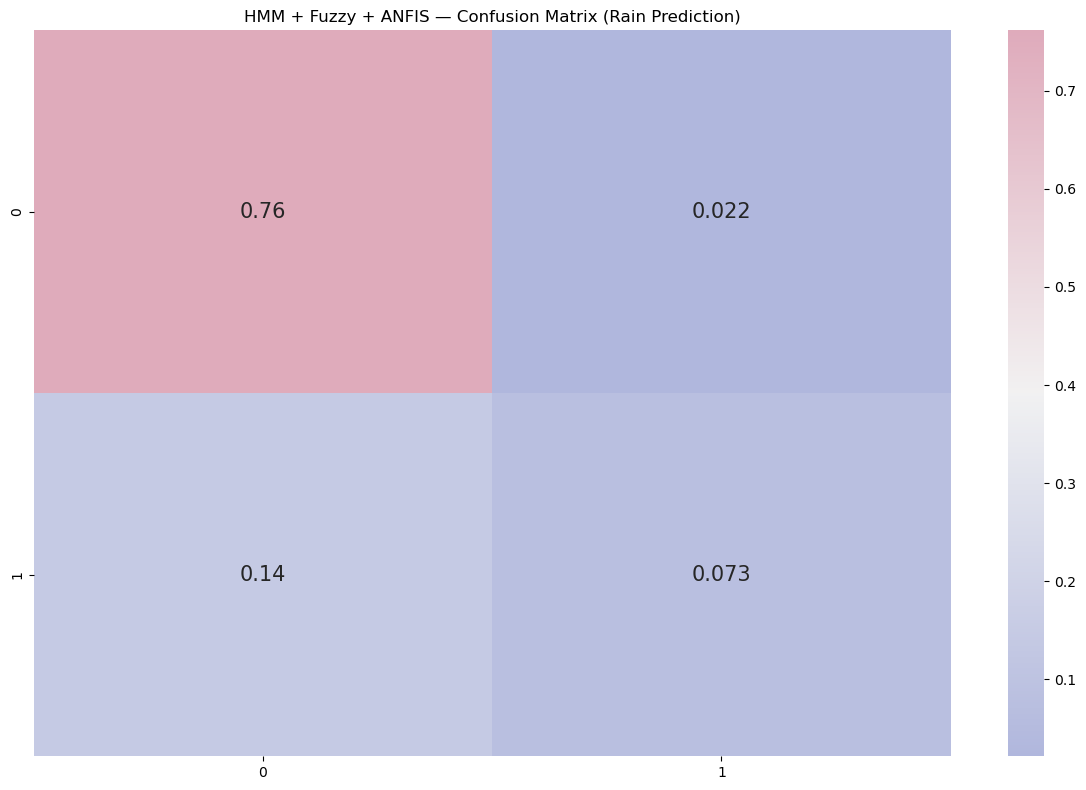

In [15]:
cmap1 = sns.diverging_palette(260, -10, s=50, l=75, n=5, as_cmap=True)
plt.subplots(figsize=(12, 8))
cf2 = confusion_matrix(y_te_w, y_pred_anfis)
sns.heatmap(cf2 / cf2.sum(), cmap=cmap1, annot=True, annot_kws={'size': 15})
plt.title('HMM + Fuzzy + ANFIS — Confusion Matrix (Rain Prediction)')
plt.tight_layout()
plt.show()


In [16]:
report2 = classification_report(y_te_w, y_pred_anfis, output_dict=True)
df_r2 = pd.DataFrame(report2).T
df_r2['support'] = df_r2['support'].astype(int)
df_r2[['precision','recall','f1-score','support']].round(2).style\
    .background_gradient(cmap='Blues', subset=['precision','recall','f1-score'])\
    .format({'precision':'{:.2f}','recall':'{:.2f}','f1-score':'{:.2f}','support':'{:d}'})


,precision,recall,f1-score,support
0,0.84,0.97,0.90,20673
1,0.77,0.34,0.47,5722
accuracy,0.83,0.83,0.83,0
macro avg,0.81,0.65,0.69,26395
weighted avg,0.83,0.83,0.81,26395
